---
## 📊 Step 2 — Exploratory Data Analysis (EDA)

### 2.1 — Basic Info & Missing Values

In [ ]:
print("=== Dataset Info ===")
print(f"Samples  : {X_all.shape[0]}")
print(f"Features : {X_all.shape[1]}")
print(f"Missing  : {X_all.isnull().sum().sum()}")
print(f"Feature range: min={X_all.min().min():.1f}, max={X_all.max().max():.1f}")
print()
print("=== Ground Truth Distribution ===")
print(y_all.value_counts())
print()
print("✅ No missing values — dataset is clean!")

=== Dataset Info ===
Samples  : 2600
Features : 500
Missing  : 0
Feature range: min=0.0, max=999.0

=== Ground Truth Distribution ===
 1    1300
-1    1300
Name: count, dtype: int64

✅ No missing values — dataset is clean!


### 2.2 — Class Distribution

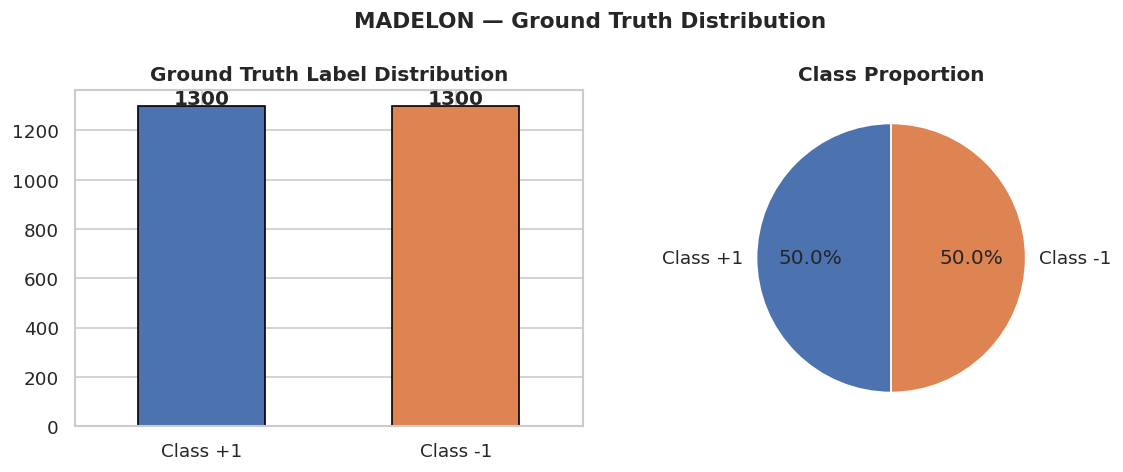

In [ ]:
class_counts = y_all.value_counts()
class_counts.index = ['Class +1', 'Class -1']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
class_counts.plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'], edgecolor='black')
axes[0].set_title('Ground Truth Distribution', fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 int(bar.get_height()), ha='center', fontweight='bold')
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0','#DD8452'], startangle=90)
axes[1].set_title('Class Proportion', fontweight='bold')
plt.suptitle('MADELON — Ground Truth Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3 — Feature Variance Distribution

Max variance : 28503.99
Min variance : 0.0
Mean variance: 8441.32


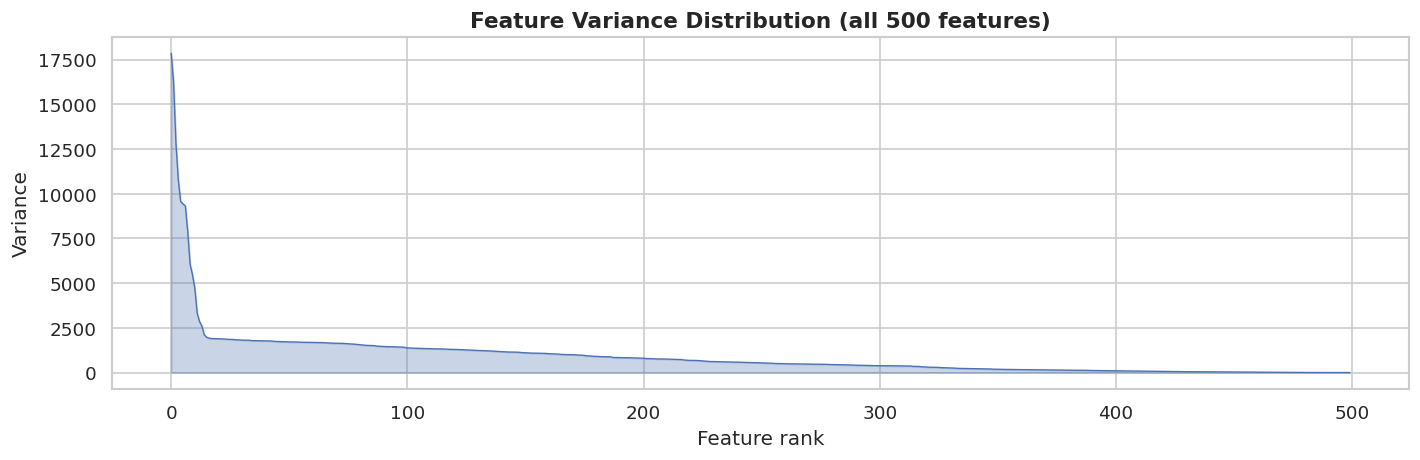

In [ ]:
variances = X_all.var().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(len(variances)), variances.values, color='#4C72B0', linewidth=0.8)
ax.fill_between(range(len(variances)), variances.values, alpha=0.3, color='#4C72B0')
ax.set_title('Feature Variance Distribution (all 500 features)', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature rank (sorted by variance)')
ax.set_ylabel('Variance')
plt.tight_layout()
plt.show()

print(f"Max variance : {variances.max():.2f}")
print(f"Min variance : {variances.min():.2f}")
print(f"Mean variance: {variances.mean():.2f}")

### 2.4 — Correlation Heatmap (Top 20 Features)

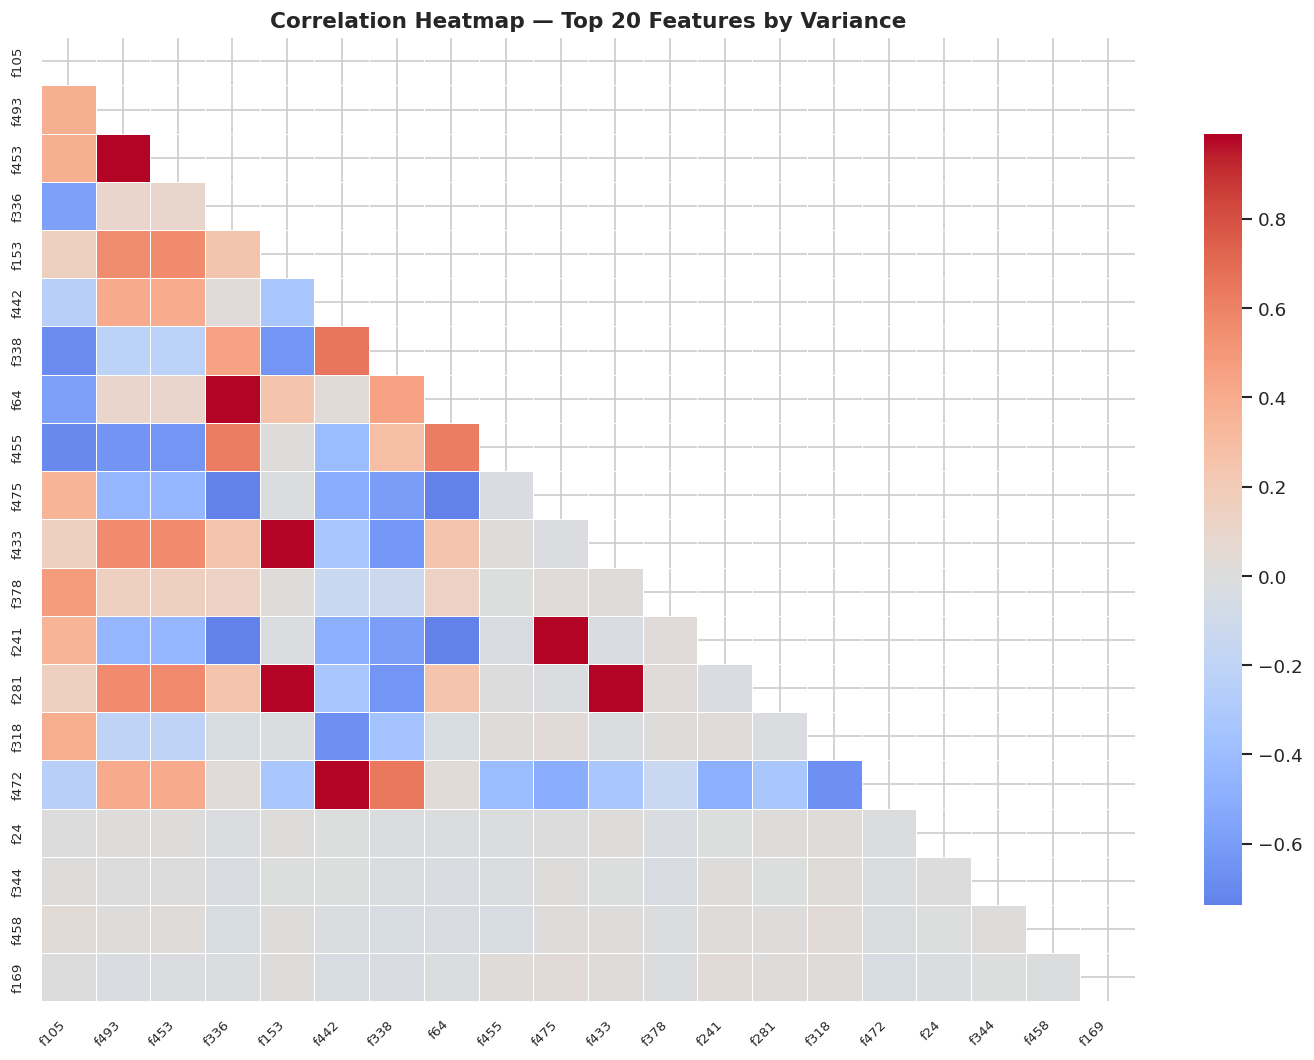

In [ ]:
top20 = variances.head(20).index.tolist()
corr = X_all[top20].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, cbar_kws={'shrink':0.8}, ax=ax)
ax.set_title('Correlation Heatmap — Top 20 Features by Variance',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()